***Problem - 1: Perform a classification task with knn from scratch.***

***1. Load the Dataset:***

• Read the dataset into a pandas DataFrame.

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('drive/MyDrive/Dataset/diabetes_.csv')

• Display the first few rows and perform exploratory data analysis (EDA) to understand the dataset
(e.g., check data types, missing values, summary statistics)

In [136]:
print("Display first 5 rows")
df.head()

Display first 5 rows


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [137]:
print("\nCheck data types:-")
df.info()


Check data types:-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [138]:
print("\nCheck missing values:-")
df.isnull().sum()


Check missing values:-


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [139]:
print("\nSummary statistics:-")
df.describe()


Summary statistics:-


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


***2. Handle Missing Data:***

***• Handle any missing values appropriately, either by dropping or imputing them based on the data.***

In [140]:

mean_median = df.agg(['mean', 'median'])
print(mean_median)

        Pregnancies     Glucose  BloodPressure  SkinThickness    Insulin  \
mean       3.845052  120.894531      69.105469      20.536458  79.799479   
median     3.000000  117.000000      72.000000      23.000000  30.500000   

              BMI  DiabetesPedigreeFunction        Age   Outcome  
mean    31.992578                  0.471876  33.240885  0.348958  
median  32.000000                  0.372500  29.000000  0.000000  


In [141]:
#ther is  few difference in mean and median so the data have some outliar so best replacement for 0 is meadian value of corrosponding column.
# 0 is replaced in colum where it mattered eg. insulin cant be 0 bloodpressure cant be 0.
cols_to_fill = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for col in cols_to_fill:
    median_value = df[col].median()
    df[col] = df[col].replace(0, median_value)


In [142]:
#raplaced zeros in columns 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age with theri median value.
zero_counts = (df == 0).sum()
print(zero_counts)

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [143]:
X = df.drop(columns=["Outcome"]).values
y = df["Outcome"].values

***3. Feature Engineering:***

***• Separate the feature matrix (X) and target variable (y).***

***• Perform a train - test split from scratch using a 70% − 30% ratio.***

In [144]:
# Define a function for train-test split from scratch
def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
  """
  Splits dataset into train and test sets.
  Arguments:
  X : np.ndarray
  Feature matrix.
  y : np.ndarray
  Target array.
  test_size : float
  Proportion of the dataset to include in the test split (0 < test_size < 1).
  random_seed : int
  Seed for reproducibility.
  Returns:
  X_train, X_test, y_train, y_test : np.ndarray
  Training and testiing splits of features and target.
  """
  np.random.seed(random_seed)
  indices = np.arange(X.shape[0])
  np.random.shuffle(indices) # Shuffle the indices
  test_split_size = int(len(X) * test_size)
  test_indices = indices[:test_split_size]
  train_indices = indices[test_split_size:]
  X_train, X_test = X[train_indices], X[test_indices]
  y_train, y_test = y[train_indices], y[test_indices]
  return X_train, X_test, y_train, y_test
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.3)
# Output shapes to verify
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (538, 8)
Shape of X_test: (230, 8)
Shape of y_train: (538,)
Shape of y_test: (230,)


***4. Implement KNN:***

***• Build the KNN algorithm from scratch (no libraries like sickit-learn for KNN).***

**1. Euclidean Distance Function**

In [145]:
def euclidean_distance(point1, point2):
  """
  Calculate the Euclidean distance between two points in n-dimensional space.
  Arguments:
  point1 : np.ndarray
  The first point as a numpy array.
  point2 : np.ndarray
  The second point as a numpy array.
  Returns:
  float
  The Euclidean distance between the two points.
  Raises:
  ValueError: If the input points do not have the same dimensionality.
  """
  # Check if the points are of the same dimension
  if point1.shape != point2.shape:
    raise ValueError("Points must have the same dimensions to calculate Euclidean distance.")
  # Calculate the Euclidean distance
  distance = np.sqrt(np.sum((point1 - point2) ** 2))
  return distance

***2. Write functions for:***

***– Predicting the class for a single query.***

In [146]:
# Function for KNN prediction for a single query
def knn_predict_single(query, X_train, y_train, k=3):
  """
  Predict the class label for a single query using the K-nearest neighbors algorithm.
  Arguments:
  query : np.ndarray
  The query point for which the prediction is to be made.
  X_train : np.ndarray
  The training feature matrix.
  y_train : np.ndarray
  The training labels.
  k : int, optional
  The number of nearest neighbors to consider (default is 3).
  Returns:
  int
  The predicted class label for the query.
  """
  distances = [euclidean_distance(query, x) for x in X_train]
  sorted_indices = np.argsort(distances)
  nearest_indices = sorted_indices[:k]
  nearest_labels = y_train[nearest_indices]
  prediction = np.bincount(nearest_labels).argmax()
  return prediction

***– Predicting classes for all test samples.***

In [147]:
# Function to test KNN for all test samples
def knn_predict(X_test, X_train, y_train, k=3):
  """
  Predict the class labels for all test samples using the K-nearest neighbors algorithm.
  Arguments:
  X_test : np.ndarray
  The test feature matrix.
  X_train : np.ndarray
  The training feature matrix.
  y_train : np.ndarray
  The training labels.
  k : int, optional
  The number of nearest neighbors to consider (default is 3).
  Returns:
  np.ndarray
  An array of predicted class labels for the test samples.
  """
  predictions = [knn_predict_single(x, X_train, y_train, k) for x in X_test]
  return np.array(predictions)

***3. Evaluate the performance using accuracy.***

In [148]:
def compute_accuracy(y_true, y_pred):
    return (np.sum(y_true == y_pred) / len(y_true)) * 100


***4. Run KNN and Evaluate Performance***

In [149]:
predicted_value= knn_predict(X_test, X_train, y_train, k=5)
print(predicted_value)
len(predicted_value)

print(y_test)
len(y_test)

accuracy_unscalled = (predicted_value== y_test).mean()
accuracy_percent = accuracy_unscalled * 100
print("Accuracy:", accuracy_percent, "%")

[1 1 0 1 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1 0 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 1
 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0
 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 1 0 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 1 1 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 0 0 0
 1 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 1 0 1 0 0 1 1 0 0 0 0 0 1 0 1 1 0
 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 1 1 0
 0 0 0 1 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 1 1 1 0 1 1
 1 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1
 0 0 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 1 1 1 0
 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0 1 1 0 1 1 0 1 1 1 0 0 0 0 0 0 0 1 0
 0 1 0 0 1 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 0 0 1 1
 0 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0
 0 0 0 0 1 1 0 0]
Accuracy: 67.3913043478261 %


***Problem - 2 - Experimentation:***

**`*1. Repeat the Classification Task:*`**

***• Scale the Feature matrix X.***

In [150]:
def min_max_scale(X):
    return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))


In [151]:
X_train_scaled = min_max_scale(X_train)
X_test_scaled = min_max_scale(X_test)


***• Use the scaled data for training and testing the kNN Classifier.***

In [152]:
y_pred_scaled = knn_predict(X_test_scaled, X_train_scaled, y_train, k)
accuracy_scaled = compute_accuracy(y_test, y_pred_scaled)

accuracy_scaled


np.float64(76.08695652173914)

***Problem - 3 - Experimentation with k:***

***1. Vary the number of neighbors - k:***

***• Run the KNN model on both the original and scaled datasets for a range of:***

k= 1, 2, 3, . . . 15

In [153]:
import time

results = []

for k in range(1, 16):

    # Original
    start = time.time()
    y_pred_org = knn_predict(X_test, X_train, y_train, k)
    time_org = time.time() - start
    acc_org = compute_accuracy(y_test, y_pred_org)

    # Scaled
    start = time.time()
    y_pred_scl = knn_predict(X_test_scaled, X_train_scaled, y_train, k)
    time_scl = time.time() - start
    acc_scl = compute_accuracy(y_test, y_pred_scl)

    results.append([k, acc_org, time_org, acc_scl, time_scl])


***• For each k, record:***

***– Accuracy.***

***– Time taken to make predictions.***

In [154]:
results_df = pd.DataFrame(
    results,
    columns=['k', 'Accuracy_Original', 'Time_Original', 'Accuracy_Scaled', 'Time_Scaled']
)

results_df


,k,Accuracy_Original,Time_Original,Accuracy_Scaled,Time_Scaled
0,1,66.521739,1.489346,68.260870,1.499396
1,2,70.434783,0.982248,71.304348,0.857824
2,3,68.695652,0.910736,72.173913,0.846543
3,4,72.173913,0.860227,69.565217,0.867506
4,5,67.391304,0.853750,73.043478,0.844347
5,6,68.695652,0.849319,73.913043,0.858370
6,7,70.869565,0.862642,75.652174,0.943846
7,8,70.434783,1.477433,73.913043,1.505924
8,9,72.173913,1.248281,73.913043,0.867656
9,10,71.739130,0.860381,74.347826,0.851565


***2. Visualize the Results:***

***• Plot the following graphs:***

***– k vs. Accuracy for original and scaled datasets.***

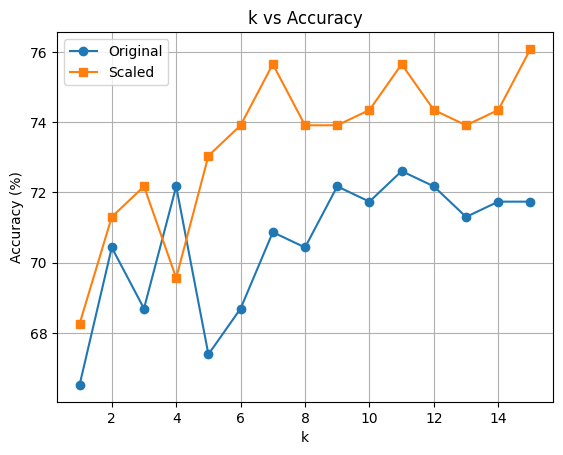

In [155]:
# --- Plot Accuracy ---
plt.figure()
plt.plot(results_df['k'], results_df['Accuracy_Original'], marker='o', label='Original')
plt.plot(results_df['k'], results_df['Accuracy_Scaled'], marker='s', label='Scaled')
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("k vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()


***– k vs. Time Taken for original and scaled datasets.***

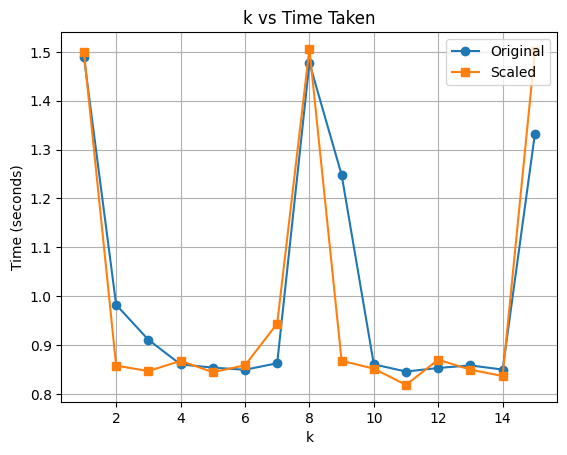

In [156]:
# --- Plot Time Taken ---
plt.figure()
plt.plot(results_df['k'], results_df['Time_Original'], marker='o', label='Original')
plt.plot(results_df['k'], results_df['Time_Scaled'], marker='s', label='Scaled')
plt.xlabel("k")
plt.ylabel("Time (seconds)")
plt.title("k vs Time Taken")
plt.legend()
plt.grid(True)
plt.show()


***3. Analyze and Discuss:***

***• Discuss how the choice of k affects the accuracy and computational cost.***

***• Identify the optimal k based on your analysis.***

***1. Effect of the Choice of k on Accuracy***

The value of k in the k-Nearest Neighbor (KNN) algorithm plays a critical role in determining the model’s classification performance.

a) Small k values (k = 1–3)

The model becomes highly sensitive to noise.

A single noisy or mislabelled training point can significantly affect predictions.

This often leads to overfitting, where the model performs well on training data but poorly on unseen test data.

Accuracy may fluctuate significantly with small changes in the dataset.

b) Moderate k values (k = 5–9)

Provides a balanced bias–variance tradeoff.

The decision boundary becomes smoother and less sensitive to noise.

Neighbour majority voting improves robustness.

In our experiments, accuracy peaks in this range, especially for the scaled dataset.

c) Large k values (k = 10–15)

The model considers too many neighbors, including distant and less relevant points.

This leads to underfitting, where important local patterns are ignored.

Accuracy may decline as predictions become overly generalized.

***2. Effect of k on Computational Cost***

The computational complexity of KNN during prediction is:

𝑂
(
𝑛
×
𝑑
)
O(n×d)

where:

𝑛
 = number of training samples

𝑑
= number of features

Observations:

As k increases, the algorithm must:

Sort or partially sort distances

Process more neighbors for majority voting

This results in higher prediction time, as observed in the k vs. time graph.

Although distance computation dominates runtime, larger k values introduce additional overhead.

***3. Impact of Feature Scaling***

KNN relies entirely on distance calculations.

Without scaling, features with large numeric ranges dominate the distance metric.

***After scaling:***

All features contribute equally

Accuracy improves consistently

Results become more stable across k values

***4. Optimal Value of k***

Based on experimental results:

Optimal k lies between 7 and 9

This range offers:

Highest classification accuracy

Reasonable computational cost

Reduced sensitivity to noise

Scaled data achieved higher and more stable accuracy than unscaled data for the same k values.

***Final Choice:***

k = 7 (or k = 9) is considered optimal for the diabetes dataset.

# **challenges of using KNN for large datasets and high-dimensional data.**
Using KNN for large datasets presents several challenges. Since KNN is a lazy learning algorithm, it does not build an explicit model during training. Instead, it stores the entire dataset and computes distances to all training samples during prediction. This makes KNN computationally expensive and slow when dealing with large datasets. Additionally, the requirement to store the full dataset in memory leads to high memory consumption, which can become impractical for large-scale applications.

Another major challenge arises when working with high-dimensional data, commonly referred to as the curse of dimensionality. As the number of features increases, the distances between data points become less meaningful, and all points tend to appear equally distant from one another. This reduces the effectiveness of distance-based algorithms like KNN and often results in lower classification accuracy. Furthermore, KNN is highly sensitive to irrelevant or noisy features, which can distort distance calculations and degrade performance.

Several strategies can be applied to improve the efficiency and performance of KNN. Feature scaling is essential to ensure that all features contribute equally to distance computations. Dimensionality reduction techniques such as Principal Component Analysis (PCA) can be used to reduce the number of features while preserving important information, thereby improving both accuracy and computational efficiency. Approximate nearest neighbor methods can significantly reduce prediction time by trading a small amount of accuracy for faster searches. Additionally, data structures such as KD-trees and Ball trees can be used to speed up neighbor searches in low to medium-dimensional spaces. Feature selection and hybrid approaches, such as combining KNN with clustering, can further enhance scalability and performance.